# Analyse Exploratoire des Données pour le Projet Diagnostic Médical Multimodal & Interprétabilité par l'IA

## Importation des bibliothèques 

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Chargement du Dataset

### Utilisation du NIH Chest X-ray Dataset disponible sur Kaggle, comprenant plus de 112 000 images de radiographies thoraciques annotées.

### Lien pour telecharger le dataset: https://www.kaggle.com/datasets/nih-chest-xrays/data

In [39]:
df = pd.read_csv('../data/Data_Entry_2017.csv') 

## Affichage de quelques enregistrements du dataset

In [40]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


## Verification des valeurs manquantes et des doublons

In [41]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

# Vérifier les doublons
print(f"Doublons : {df.duplicated().sum()}")

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64
Doublons : 0


## Détecter les erreurs d'âge (Outliers)

In [43]:

# Il arrive que certains patients aient un âge enregistré à 400 ans par erreur
print(df['Patient Age'].describe())

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


## Suppression des enregistrements dont l'age est superieur à 100 ans

In [44]:
df = df[df['Patient Age'] < 100]

## Compter les frequences de chaque pathologie

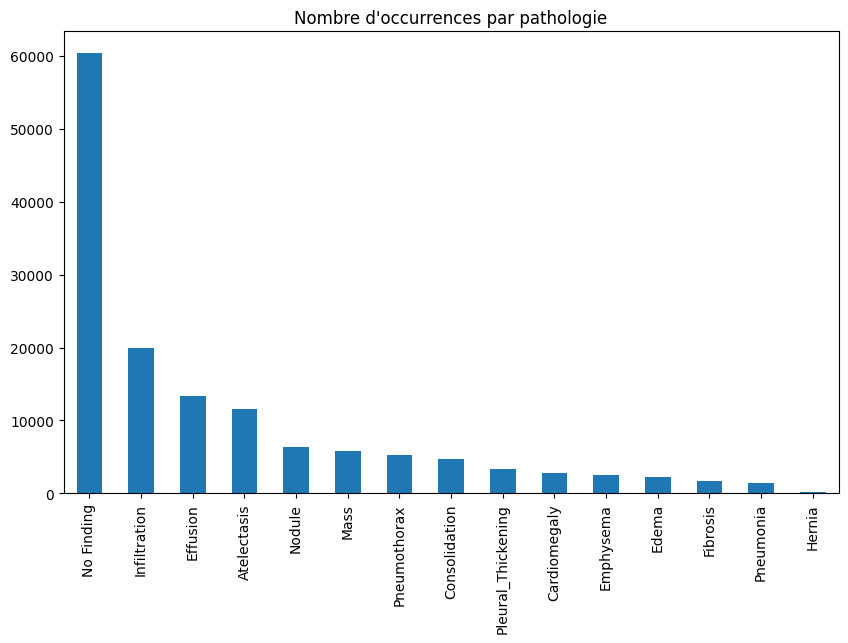

In [45]:
# Séparer les labels et compter leur fréquence
all_labels = df['Finding Labels'].str.split('|', expand=True).stack().value_counts()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
all_labels.plot(kind='bar')
plt.title('Nombre d\'occurrences par pathologie')
plt.show()

## Distribution de l'âge par genre

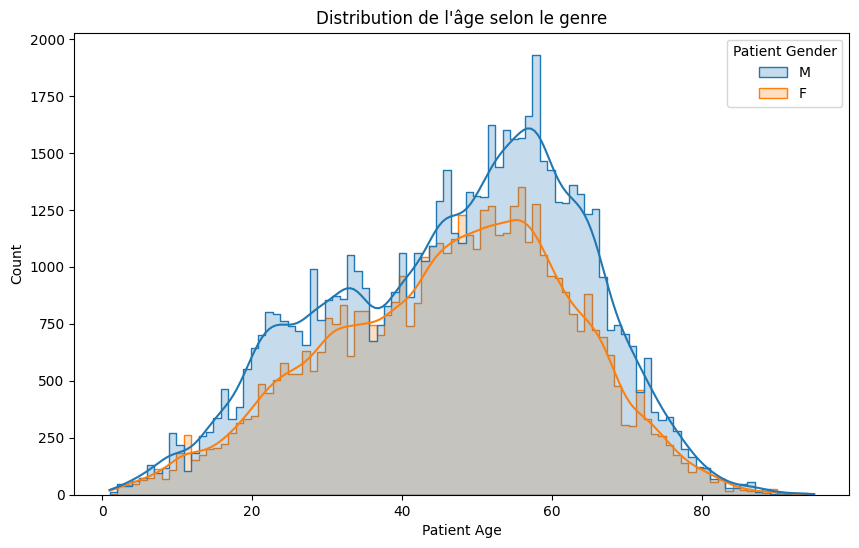

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Patient Age', hue='Patient Gender', kde=True, element="step")
plt.title('Distribution de l\'âge selon le genre')
plt.show()

In [47]:
patient_counts = df['Patient ID'].value_counts()
multiple_images = patient_counts[patient_counts > 1].count()
print(f"{multiple_images} patients ont plus d'une radiographie.")

13301 patients ont plus d'une radiographie.


## One Hot Encoding sur les labels

In [48]:
labels = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

In [49]:
for label in labels:
    # On crée une nouvelle colonne pour chaque maladie
    df[label] = df['Finding Labels'].map(lambda x: 1 if label in x else 0)

# Maintenant, vérifie à nouveau
print(df.head())

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x  ...  Mass  Nodule  Pneumonia  Pneumothorax  \
0                        0

## Corrélations entre les Pathologies 

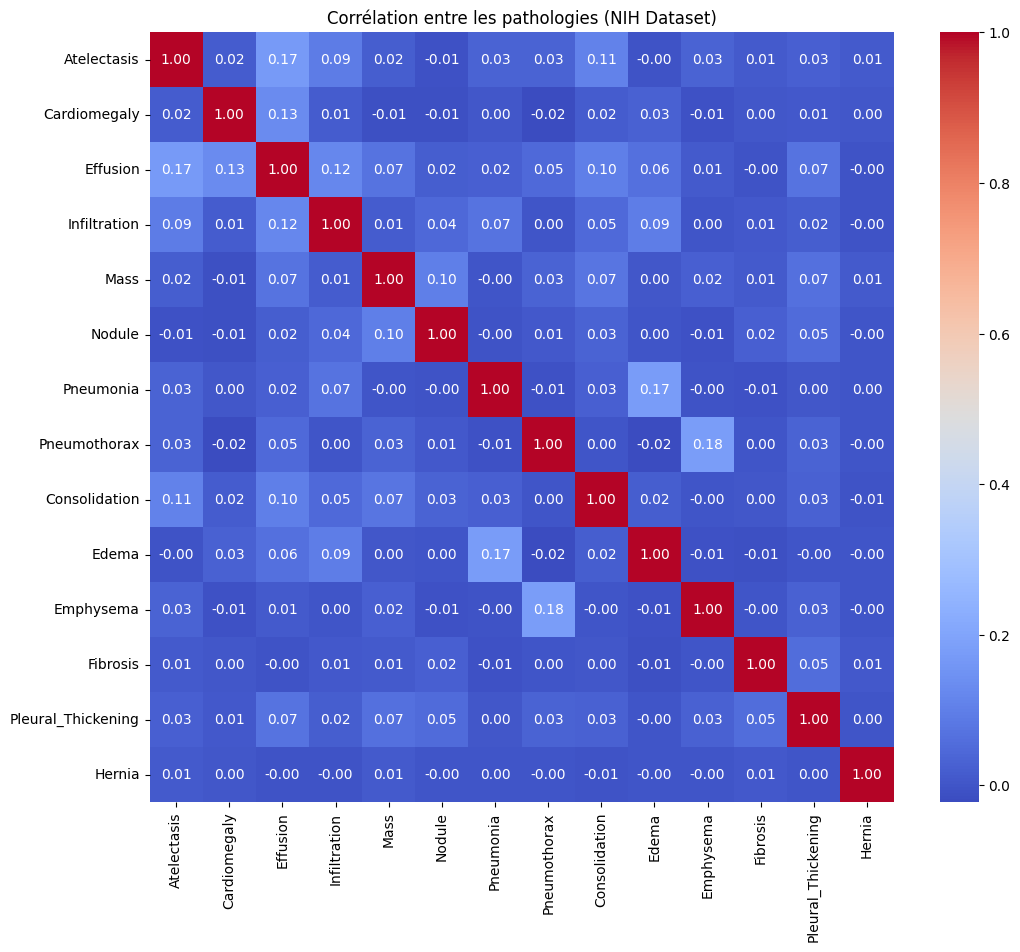

In [50]:

plt.figure(figsize=(12, 10))
sns.heatmap(df[labels].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélation entre les pathologies (NIH Dataset)')
plt.show()

In [51]:
view_counts = df.groupby(['View Position', 'Finding Labels']).size().unstack(fill_value=0)
# Regarde si la distribution change selon la position

## Nombre d'Images par Patient

Nombre maximum d'images pour un seul patient : 184


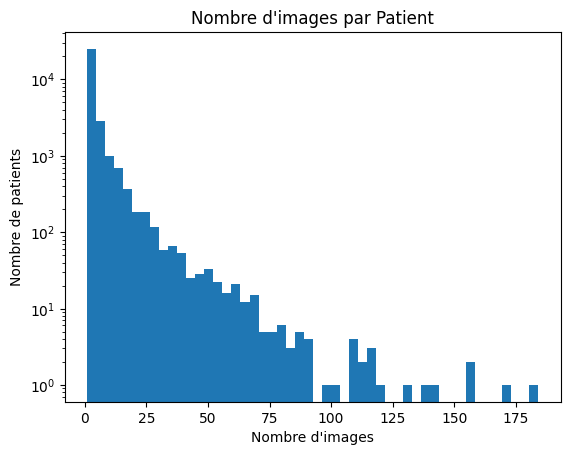

In [52]:
patient_counts = data['Patient ID'].value_counts()
print(f"Nombre maximum d'images pour un seul patient : {patient_counts.max()}")

# Visualisation
plt.hist(patient_counts, bins=50)
plt.title('Nombre d\'images par Patient')
plt.xlabel('Nombre d\'images')
plt.ylabel('Nombre de patients')
plt.yscale('log') # Utilise l'échelle log pour mieux voir les extrêmes
plt.show()